<a href="https://www.kaggle.com/code/mariammouh/mini-project-cv?scriptVersionId=303627752" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_5071.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_5031.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_314.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_2550.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_2234.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_3188.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1324.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1590.png
/

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import timm
from sklearn.metrics import accuracy_score, precision_score, f1_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# Fine tune all


In [3]:


# ============================================================
# 1. CONFIGURATION
# ============================================================
BASE_PATH = "/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD"

CONFIG = {
    "train_dir": os.path.join(BASE_PATH, "LCC_FASD_training"),
    "val_dir":   os.path.join(BASE_PATH, "LCC_FASD_development"),
    "test_dir":  os.path.join(BASE_PATH, "LCC_FASD_evaluation"),
    "img_size":     224,
    "batch_size":   32,
    "epochs":       20,
    "lr":           1e-4,
    "weight_decay": 1e-4,
    "num_classes":  2,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42
}

print(f"Device utilisé : {CONFIG['device']}")

# ============================================================
# 2. DATASET
# ============================================================
class FaceAntiSpoofDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.image_paths = []
        self.labels = []
        self.transform = transform

        # real -> label 1
        real_dir = os.path.join(data_dir, "real")
        for fname in os.listdir(real_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                self.image_paths.append(os.path.join(real_dir, fname))
                self.labels.append(1)

        # spoof -> label 0
        spoof_dir = os.path.join(data_dir, "spoof")
        for fname in os.listdir(spoof_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                self.image_paths.append(os.path.join(spoof_dir, fname))
                self.labels.append(0)

        print(f"  {os.path.basename(data_dir)} → real: {self.labels.count(1)} | spoof: {self.labels.count(0)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# ============================================================
# 3. TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# ============================================================
# 4. MODELE — FINE-TUNE ALL
# ============================================================
def build_model():
    model = timm.create_model(
        'swin_base_patch4_window7_224',
        pretrained=True,
        num_classes=CONFIG["num_classes"]
    )

    # Dégeler TOUTES les couches
    for param in model.parameters():
        param.requires_grad = True

    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nStratégie        : Fine-tune ALL")
    print(f"Paramètres entraînables : {total:,}")
    return model


# ============================================================
# 5. SAMPLER (gérer le déséquilibre des classes)
# ============================================================
def get_sampler(labels):
    class_counts = np.bincount(labels)
    weights = 1.0 / class_counts
    sample_weights = [weights[l] for l in labels]
    return WeightedRandomSampler(sample_weights, len(sample_weights))


# ============================================================
# 6. ENTRAINEMENT
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for imgs, labels in tqdm(loader, desc="  Train"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


# ============================================================
# 7. EVALUATION
# ============================================================
def evaluate(model, loader, criterion, device, split="Val"):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f"  {split}"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)

    return total_loss / len(loader), acc, prec, f1

Device utilisé : cuda



📂 Chargement des données :
  LCC_FASD_training → real: 1302 | spoof: 7444
  LCC_FASD_development → real: 416 | spoof: 2590
  LCC_FASD_evaluation → real: 323 | spoof: 7312


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]


Stratégie        : Fine-tune ALL
Paramètres entraînables : 86,745,274

Epoch 1/20


  Val: 100%|██████████| 94/94 [00:43<00:00,  2.14it/s]


  Train → Loss: 0.1124 | Acc: 89.84%
  Val   → Loss: 2.1394 | Acc: 45.01% | Précision: 20.11% | F1: 33.48%
  Meilleur modèle sauvegardé (F1=33.48%)

Epoch 2/20


...

  Train → Loss: 0.0005 | Acc: 99.99%
  Val   → Loss: 0.0374 | Acc: 98.87% | Précision: 98.23% | F1: 95.81%

Epoch 20/20


  Val: 100%|██████████| 94/94 [00:42<00:00,  2.23it/s]


  Train → Loss: 0.0002 | Acc: 99.99%
  Val   → Loss: 0.0394 | Acc: 98.84% | Précision: 98.47% | F1: 95.67%

 Évaluation finale sur le Test Set :


  Test: 100%|██████████| 239/239 [01:47<00:00,  2.23it/s]



 Résultats Finaux (Fine-tune ALL)
  Accuracy  : 96.97%
  Précision : 59.54%
  F1-Score  : 71.30%


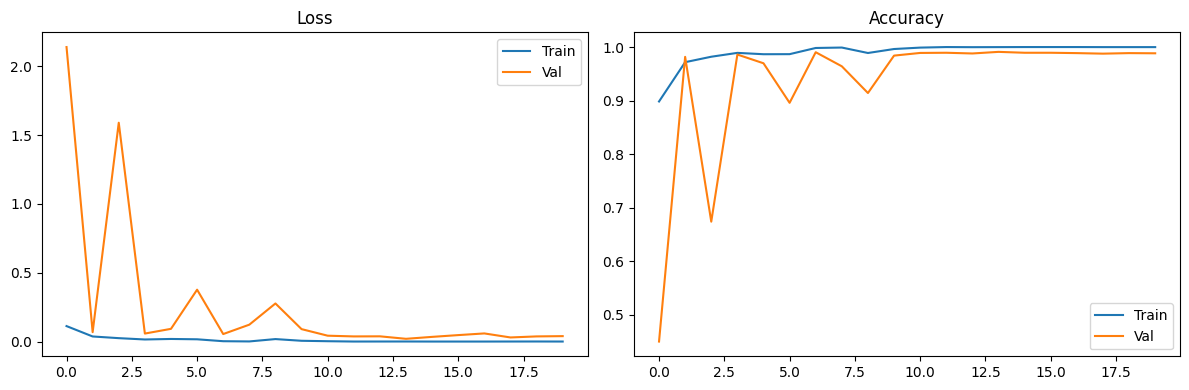

In [4]:

# ============================================================
# 8. PIPELINE PRINCIPAL
# ============================================================
def main():
    torch.manual_seed(CONFIG["seed"])

    # --- Datasets ---
    print("\n📂 Chargement des données :")
    train_dataset = FaceAntiSpoofDataset(CONFIG["train_dir"], train_transform)
    val_dataset   = FaceAntiSpoofDataset(CONFIG["val_dir"],   val_transform)
    test_dataset  = FaceAntiSpoofDataset(CONFIG["test_dir"],  val_transform)

    # --- Dataloaders ---
    sampler = get_sampler(train_dataset.labels)

    train_loader = DataLoader(train_dataset,
                              batch_size=CONFIG["batch_size"],
                              sampler=sampler,
                              num_workers=2,
                              pin_memory=True)

    val_loader   = DataLoader(val_dataset,
                              batch_size=CONFIG["batch_size"],
                              shuffle=False,
                              num_workers=2,
                              pin_memory=True)

    test_loader  = DataLoader(test_dataset,
                              batch_size=CONFIG["batch_size"],
                              shuffle=False,
                              num_workers=2,
                              pin_memory=True)

    # --- Modèle ---
    model = build_model().to(CONFIG["device"])

    # --- Loss avec poids ---
    counts = np.bincount(train_dataset.labels)
    weights = torch.tensor(1.0 / counts, dtype=torch.float).to(CONFIG["device"])
    criterion = nn.CrossEntropyLoss(weight=weights)

    # --- Optimiseur & Scheduler ---
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=CONFIG["lr"],
                                  weight_decay=CONFIG["weight_decay"])

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["epochs"]
    )

    # --- Boucle d'entraînement ---
    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
    best_f1 = 0

    for epoch in range(CONFIG["epochs"]):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch+1}/{CONFIG['epochs']}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, CONFIG["device"]
        )
        val_loss, val_acc, val_prec, val_f1 = evaluate(
            model, val_loader, criterion, CONFIG["device"], "Val"
        )
        scheduler.step()

        print(f"  Train → Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
        print(f"  Val   → Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}% | Précision: {val_prec*100:.2f}% | F1: {val_f1*100:.2f}%")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_finetune_all.pth")
            print(f"  Meilleur modèle sauvegardé (F1={best_f1*100:.2f}%)")

    # --- Test final ---
    print("\n Évaluation finale sur le Test Set :")
    model.load_state_dict(torch.load("best_finetune_all.pth"))
    _, test_acc, test_prec, test_f1 = evaluate(
        model, test_loader, criterion, CONFIG["device"], "Test"
    )
    print(f"\n Résultats Finaux (Fine-tune ALL)")
    print(f"  Accuracy  : {test_acc*100:.2f}%")
    print(f"  Précision : {test_prec*100:.2f}%")
    print(f"  F1-Score  : {test_f1*100:.2f}%")

    # --- Courbes ---
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"],   label="Val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train")
    plt.plot(history["val_acc"],   label="Val")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.savefig("courbes_finetune_all.png")
    plt.show()


main()